### **Falcon9 Random Walk**

This notebook invokes the local Gymnasium-compatible `Falcon9-v0` environment, lists the configurable environment parameters, runs one episode with random actions, and saves the rendered frames as a GIF.

The goal here is not learning. It is a smoke test and visualization pass for the environment dynamics, action space, observation vector, rewards, termination, and renderer.

In [1]:
import os
import random
import sys
import time
import importlib

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from IPython.display import Image as IPImage, display

# Importing this module registers the environment id `Falcon9-v0` with Gymnasium.
# Reloading is useful in notebooks because Gymnasium can keep an old registry
# entry alive while you are editing the local environment code.
import falcon9
import falcon9.falcon9 as falcon9_env
importlib.reload(falcon9_env)
importlib.reload(falcon9)
falcon9.register_falcon9_env()

# Keep notebook stderr noise in one file, as in the training notebooks.
sys.stderr = open("err.txt", "w")

In [2]:
# Reproducibility: the policy is random, but these seeds make the sampled
# action sequence and the reset state repeatable.
SEED = 42
MAX_STEPS = 600

random.seed(SEED)
np.random.seed(SEED)

#### **Invoke the Falcon9 Environment**

The cell below intentionally spells out every `Falcon9` constructor parameter. Most examples only pass a few of these values, but keeping the full invocation visible makes the environment configuration explicit.

In [3]:
# Gymnasium creates the environment through the registered id.
# Every keyword below is forwarded to falcon9.falcon9.Falcon9.__init__.
env = gym.make(
    "Falcon9-v0",
    render_mode=None,          # None: no rendering; "rgb_array": return frame arrays; "human": open a Pygame window.
    continuous=False,          # False: Discrete(4) actions; True: continuous Box(-1, 1, shape=(2,)) controls.
    gravity=-10.0,             # Vertical Box2D gravity. Must be between -12 and 0.
    enable_wind=False,         # If True, apply horizontal wind force to the booster.
    wind_power=5.0,            # Wind force magnitude used when wind is enabled.
    wind_direction=0.0,        # Wind direction. Float controls x direction; tuple can specify an x/y direction vector.
    variable_wind=True,        # If True, wind varies over time with a deterministic pattern.
    platform_speed=1.15 / 3.0, # Horizontal speed of the moving drone-ship platform.
    max_jet_fires=50,          # Maximum number of engine/attitude-jet firings available in an episode.
    success_reward=100.0,      # Terminal reward for a successful stable landing.
    failure_reward=-100.0,     # Terminal reward for a crash, timeout, unsafe impact, or other failure.
    shaping_factor=1.0,        # Multiplier for dense reward shaping between consecutive states.
    dashboard=True,            # If True, overlay the diagnostic dashboard on rendered frames.
    max_episode_steps=MAX_STEPS # Internal step cap. None disables the environment's own timeout.
)

state, info = env.reset(seed=SEED)
print(type(env.unwrapped).__name__)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Initial state shape:", state.shape)
print("Initial info:", info)
env.close()

Falcon9
Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
   0.          0.         -1.         -2.          0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.         1.         2.         1.       ], (11,), float32)
Action space: Discrete(4)
Initial state shape: (11,)
Initial info: {}


#### **Observation and Action Meaning**

A random policy does not use the state, but labeling the vector helps when checking the logged trajectory.

In [5]:
observation_labels = [
    "relative_x_to_platform",
    "relative_y_to_landing_target",
    "relative_x_velocity",
    "vertical_velocity",
    "booster_angle",
    "angular_velocity",
    "left_foot_contact",
    "right_foot_contact",
    "platform_x",
    "platform_x_velocity",
    "jet_fire_fraction_remaining",
]

action_meaning = {
    0: "do nothing",
    1: "fire upper-left attitude jet",
    2: "fire bottom engine",
    3: "fire upper-right attitude jet",
}

for index, label in enumerate(observation_labels):
    print(f"{index:02d}: {label}")

print("Discrete actions:")
for action, meaning in action_meaning.items():
    print(f"{action}: {meaning}")

00: relative_x_to_platform
01: relative_y_to_landing_target
02: relative_x_velocity
03: vertical_velocity
04: booster_angle
05: angular_velocity
06: left_foot_contact
07: right_foot_contact
08: platform_x
09: platform_x_velocity
10: jet_fire_fraction_remaining
Discrete actions:
0: do nothing
1: fire upper-left attitude jet
2: fire bottom engine
3: fire upper-right attitude jet


#### **Random Walk Episode**

The agent samples uniformly from the environment action space at each step. Frames are collected with `render_mode="rgb_array"`, matching the rendering approach used by the Falcon9 training notebooks.

In [6]:
def run_random_walk(seed=SEED, max_steps=MAX_STEPS):
    render_env = gym.make(
        "Falcon9-v0",
        render_mode="rgb_array",
        continuous=False,
        gravity=-10.0,
        enable_wind=False,
        wind_power=5.0,
        wind_direction=0.0,
        variable_wind=True,
        platform_speed=1.15 / 3.0,
        max_jet_fires=50,
        success_reward=100.0,
        failure_reward=-100.0,
        shaping_factor=1.0,
        dashboard=True,
        max_episode_steps=max_steps,
    )
    render_env.action_space.seed(seed)

    frames = []
    rewards = []
    actions = []
    states = []

    state, info = render_env.reset(seed=seed)
    states.append(state)

    reset_frame = render_env.render()
    frames.extend([reset_frame] * 8)

    terminated = False
    truncated = False
    step_info = info

    for step in range(max_steps):
        frames.append(render_env.render())

        action = render_env.action_space.sample()
        next_state, reward, terminated, truncated, step_info = render_env.step(action)

        actions.append(action)
        rewards.append(float(reward))
        states.append(next_state)
        state = next_state

        if terminated or truncated:
            terminal_frame = render_env.render()
            frames.extend([terminal_frame] * 12)
            break

    render_env.close()

    return {
        "frames": frames,
        "states": np.array(states),
        "actions": np.array(actions),
        "rewards": np.array(rewards),
        "terminated": terminated,
        "truncated": truncated,
        "info": step_info,
    }

random_walk = run_random_walk()

print("Steps:", len(random_walk["actions"]))
print("Total reward:", random_walk["rewards"].sum())
print("Terminated:", random_walk["terminated"])
print("Truncated:", random_walk["truncated"])
print("Final info:", random_walk["info"])
print("Action counts:", {action_meaning[a]: int((random_walk["actions"] == a).sum()) for a in action_meaning})

Steps: 257
Total reward: -438.4270971679687
Terminated: True
Truncated: False
Final info: {'success': False, 'failure_reason': 'out_of_bounds', 'platform_x': 7.078227996826172, 'platform_impact_velocity': None, 'wind_power': 0.0, 'wind_direction': 0.0, 'jet_fires_used': 50, 'jet_fires_remaining': 0, 'stable_landing_steps': 0, 'anchored_feet': (), 'left_foot_contact': False, 'right_foot_contact': False, 'body_platform_contact': False, 'platform_contact': False}
Action counts: {'do nothing': 59, 'fire upper-left attitude jet': 71, 'fire bottom engine': 65, 'fire upper-right attitude jet': 62}


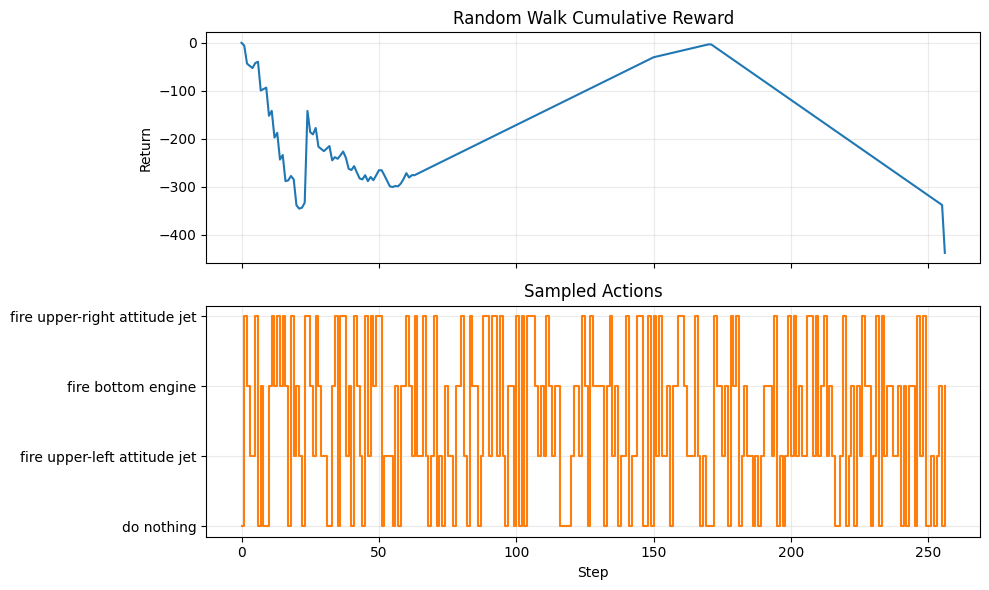

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(np.cumsum(random_walk["rewards"]), color="tab:blue")
axes[0].set_ylabel("Return")
axes[0].set_title("Random Walk Cumulative Reward")
axes[0].grid(alpha=0.25)

axes[1].step(np.arange(len(random_walk["actions"])), random_walk["actions"], where="post", color="tab:orange")
axes[1].set_yticks(list(action_meaning.keys()))
axes[1].set_yticklabels(list(action_meaning.values()))
axes[1].set_xlabel("Step")
axes[1].set_title("Sampled Actions")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

#### **Visualize the Frames**

The helper below saves the collected `rgb_array` frames as an animated GIF, using the same PIL frame conversion pattern as the other Falcon9 notebooks.

Saved 277 frames to ./FALCON9_Random_Walk.gif


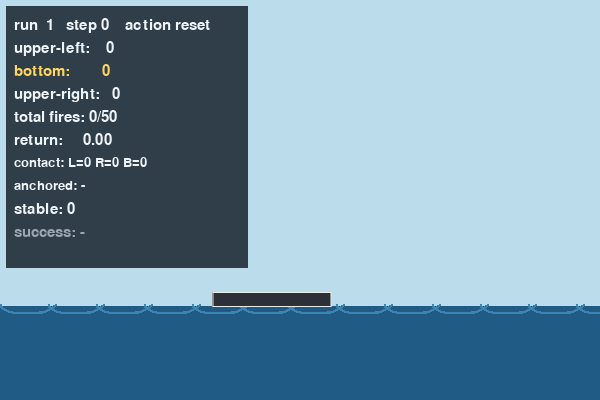

In [8]:
def save_frames_as_gif(frames, path="./", filename="FALCON9_Random_Walk.gif", frame_ms=40):
    if not frames:
        print("No frames were collected.")
        return None

    images = [Image.fromarray(frame) for frame in frames]
    gif_path = os.path.join(path, filename)
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=frame_ms,
        loop=0,
    )
    print(f"Saved {len(frames)} frames to {gif_path}")
    return gif_path

gif_path = save_frames_as_gif(random_walk["frames"])
display(IPImage(filename=gif_path))

In [9]:
# Optional environment/version report, matching the style of the training notebooks.
import session_info
session_info.show(html=False, dependencies=True)

-----
PIL                 10.4.0
falcon9             NA
gymnasium           1.2.3
matplotlib          3.10.7
numpy               2.2.6
session_info        v1.0.1
-----
Box2D                       2.3.5
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        25.3.0
attrs                       25.3.0
babel                       2.17.0
certifi                     2025.07.14
cffi                        2.0.0
charset_normalizer          3.4.2
comm                        0.2.3
cycler                      0.12.1
cython_runtime              NA
dateutil                    2.9.0.post0
debugpy                     1.8.15
decorator                   5.2.1
defusedxml                  0.7.1
exceptiongroup              1.3.0
executing                   2.2.0
farama_notifications        NA
fastjsonschema              NA
fqdn                        NA
google                      NA
idna                        3.10
ipykernel             